In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('../data/cancer_classification.csv')

In [22]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [24]:
n = 29
target = "benign_0__mal_1"
corr = df.select_dtypes(include=np.number).corr()

In [25]:
x = corr.nlargest(n,target).index
corr_df = df[list(x)]
corr = corr_df.corr()

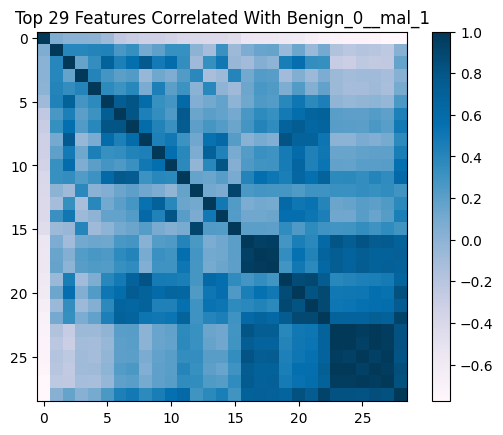

In [26]:
plt.imshow(corr, cmap="PuBu")
plt.title("Top " + str(n) + " Features Correlated With " + str(target).capitalize())
plt.colorbar()
plt.show()

In [27]:
df.rename(columns={'benign_0__mal_1': 'type'}, inplace=True)

In [28]:
corr = df.corr().type

In [29]:
avg_corr =  (sum(corr) - 1) / (len(corr) -1)

In [30]:
corr.sort_values(key=abs, ascending=False)

type                       1.000000
worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
smoothness error           0

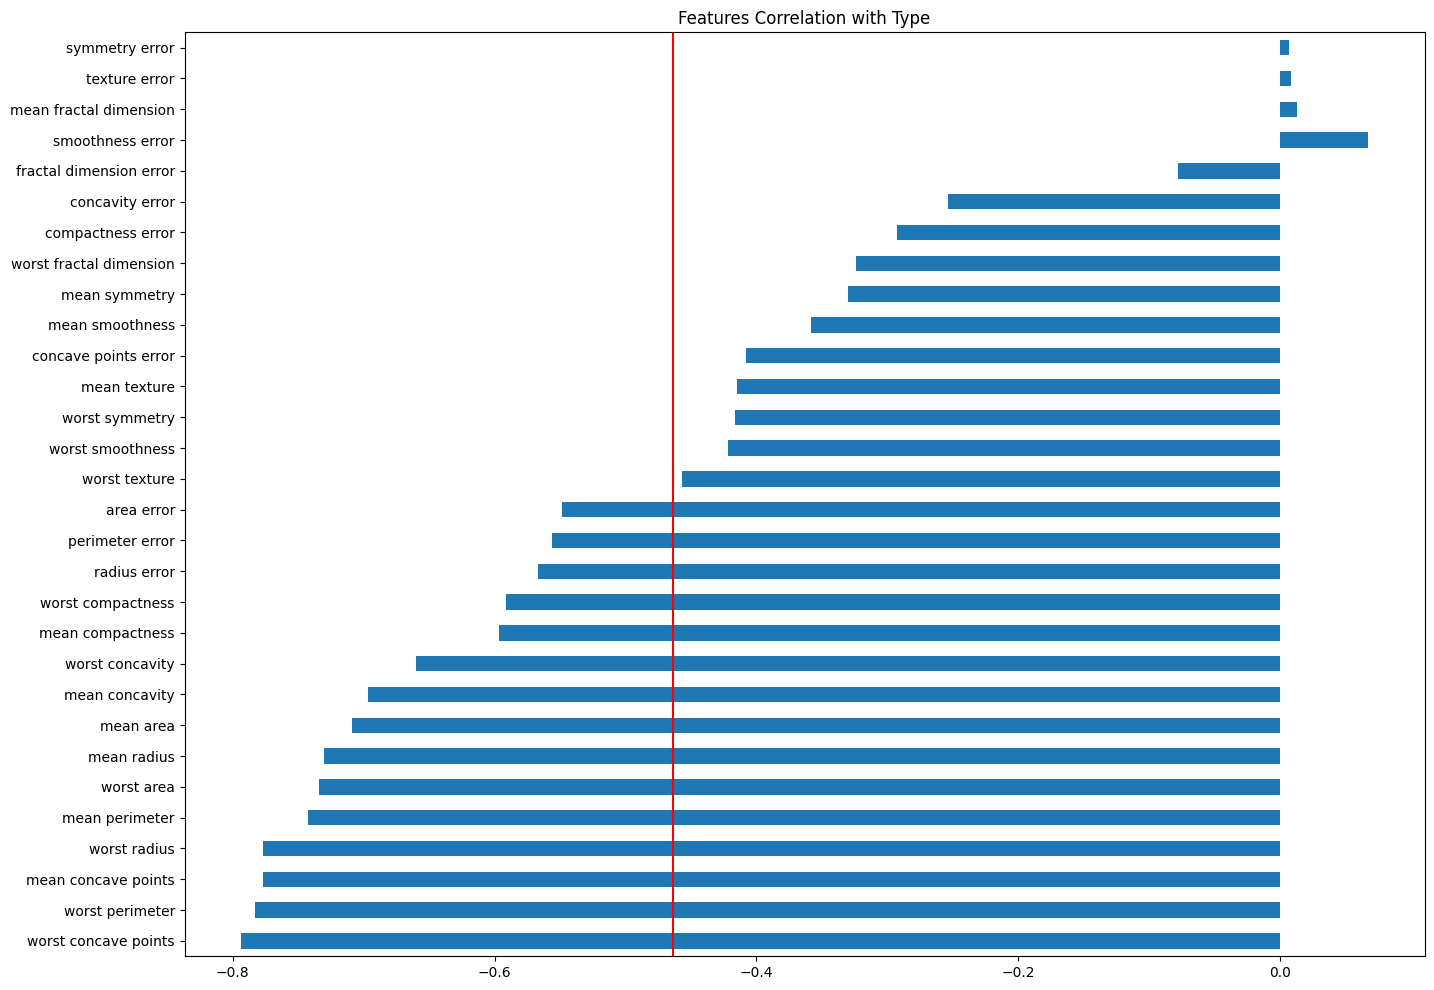

In [31]:
corr = df.corr().type
corr.sort_values(key=abs, ascending=False)[1:].plot(kind='barh', figsize=(16, 12), title='Features Correlation with Type')

avg_corr =  (sum(corr) - 1) / (len(corr) -1)
plt.axvline(x=avg_corr, color='red');

<Axes: xlabel='type', ylabel='count'>

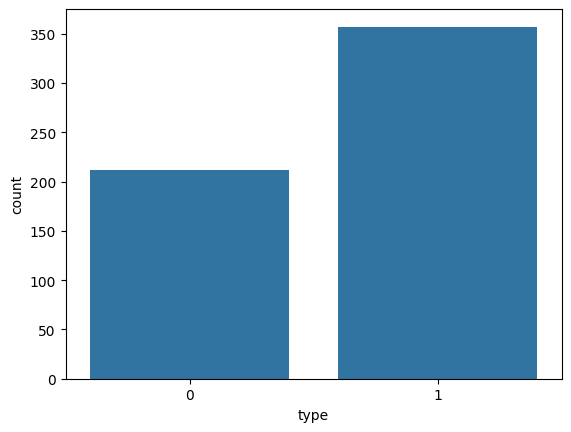

In [32]:
sns.countplot(x=df.type)

In [33]:
X = df.drop('type', axis=1)
y = df.type

In [34]:
from imblearn.over_sampling import ADASYN

In [35]:
adasyn = ADASYN(random_state=42)
x_adasyn,y_adasyn = adasyn.fit_resample(X,y)
df = x_adasyn.join(y_adasyn)

<Axes: xlabel='type', ylabel='count'>

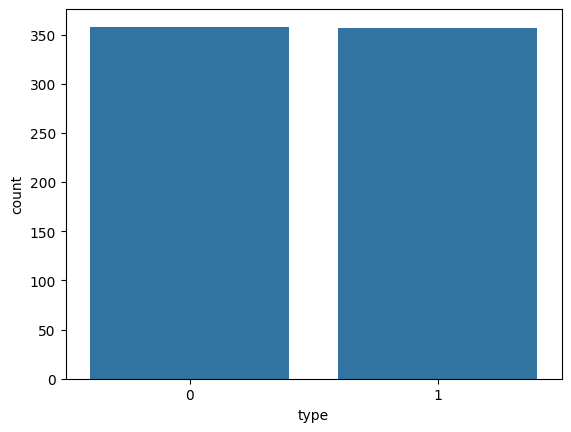

In [36]:
sns.countplot(x=df.type)

In [37]:
from sklearn.model_selection import StratifiedShuffleSplit

In [38]:
train_set = None
test_set = None 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [39]:
for train_idx, test_idx in split.split(df, df["type"]):
    train_set = df.loc[train_idx]
    test_set = df.loc[test_idx]

In [40]:
X_train = train_set.drop("type", axis=1)
y_train = train_set["type"].copy()

X_test = test_set.drop("type", axis=1)
y_test = test_set["type"].copy()

In [41]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

In [42]:
XT = RobustScaler().fit_transform(X_train)
pca = PCA(n_components=0.99)
XT = pca.fit_transform(XT)

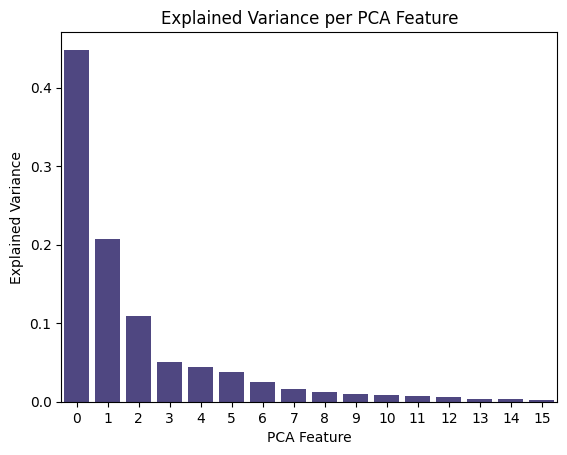

In [43]:
sns.barplot(
    x=list(range(pca.n_components_)),
    y=pca.explained_variance_ratio_,
    color="darkslateblue"
)
plt.xlabel("PCA Feature")
plt.ylabel("Explained Variance")
plt.title("Explained Variance per PCA Feature")
plt.show()

In [44]:
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

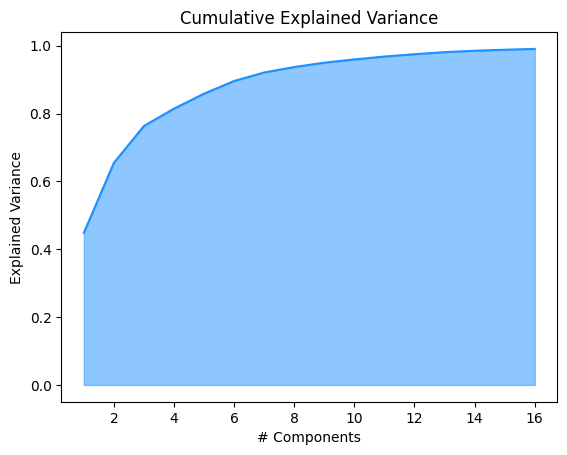

In [45]:
plt.fill_between(range(1, exp_var_cumul.shape[0] + 1), exp_var_cumul, color="dodgerblue", alpha=0.5)
plt.plot(range(1, exp_var_cumul.shape[0] + 1), exp_var_cumul, color="dodgerblue")
plt.xlabel("# Components")
plt.ylabel("Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

In [46]:
from sklearn.pipeline import Pipeline

In [47]:
pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("pca", PCA())
])
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [49]:
param_grid = {'C': np.logspace(-5, 8, 15)}
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg, param_grid, cv=10,refit=True).fit(X_train,y_train)
logreg_cv = LogisticRegression(**logreg_cv.best_params_)

In [50]:
rnd_clf = RandomForestClassifier(n_estimators=2500, max_leaf_nodes=2, n_jobs=-1,
                                 max_features="sqrt")

In [51]:
knn_clf = KNeighborsClassifier()
knn_param_grid = {"n_neighbors": list(np.arange(1, 100, 2))}
knn_clf_cv = GridSearchCV(knn_clf, knn_param_grid, cv=10,refit=True).fit(X_train,y_train)
knn_clf_cv = KNeighborsClassifier(**knn_clf_cv.best_params_)

In [52]:
svm_clf = SVC()
svc_param_grid = {'C': np.logspace(-3, 2, 6), 'gamma': np.logspace(-3, 2, 6), }
svm_clf_cv = GridSearchCV(svm_clf, svc_param_grid, cv=5)

In [53]:
col_names = ["Classifier Name", "Accuracy Score", "Precision Score",
             "Recall Score", "F1 Score"]
summary_df = pd.DataFrame(columns=col_names)

est_name = []
est_acc = []
precision_score = []
recall_score = []
f1score = []
est_conf_matrix = []


In [54]:
estimators = [
    ("LogisticRegression", logreg_cv),
    ("RandomForestClassifier ", rnd_clf),
    ("KNeighborsClassifier", knn_clf_cv),
    ("SupportVectorClassifier", svm_clf_cv)]

In [55]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [56]:
for i in range(0, len(estimators)):
    clf_name = estimators[i][0]
    clf = estimators[i][1]
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    # print(pd.crosstab(y_test,y_pred,rownames=["Actual"],colnames=["predicted"],margins=True))
    est_name.append(estimators[i][0])
    est_acc.append(accuracy_score(y_test, y_pred))
    scores = classification_report(y_test, y_pred)
    precision_score.append(scores[0])
    recall_score.append(scores[1])
    f1score.append(scores[2])
    est_conf_matrix.append(confusion_matrix(y_test,y_pred))

In [57]:
summary_df[col_names[0]] = est_name
summary_df[col_names[1]] = est_acc
summary_df[col_names[2]] = precision_score
summary_df[col_names[3]] = recall_score
summary_df[col_names[4]] = f1score

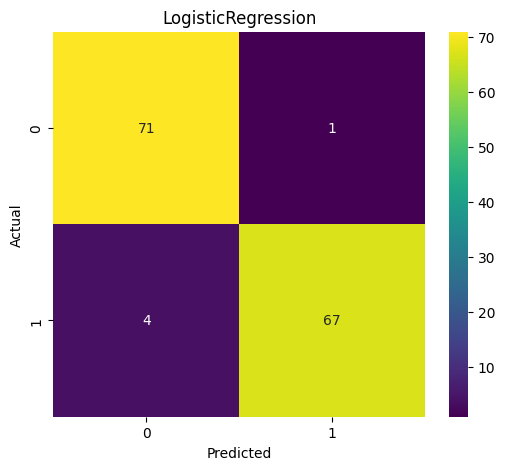

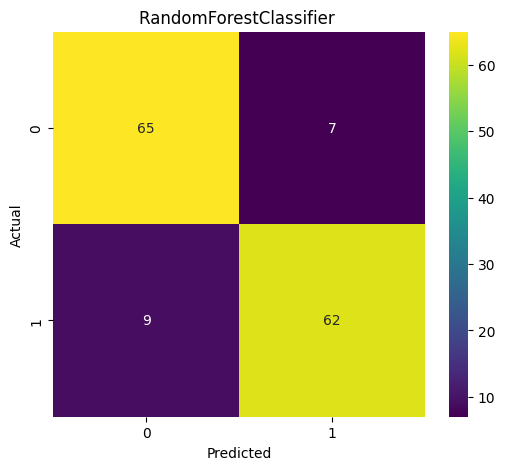

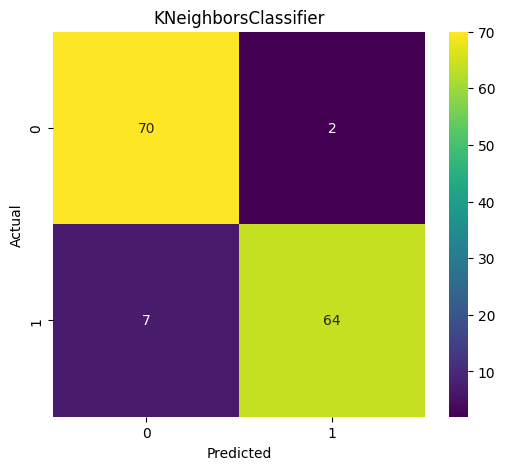

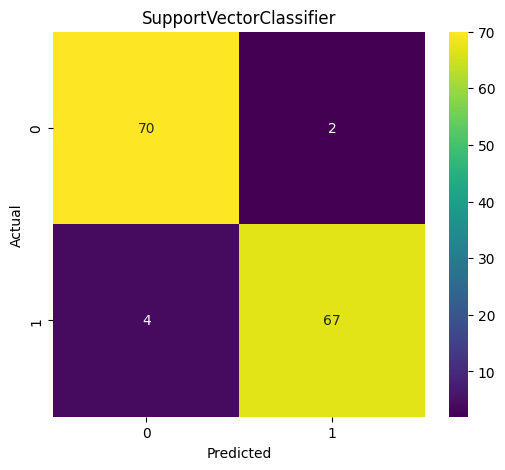

In [58]:
for i in range(len(est_conf_matrix)):
    plt.figure(figsize=(6, 5))
    sns.heatmap(est_conf_matrix[i], annot=True, fmt="d", cmap="viridis")
    plt.title(est_name[i])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [59]:
import joblib

In [60]:
joblib.dump(svm_clf_cv, "svm_cancer_classification_model.pkl")

['svm_cancer_classification_model.pkl']